# `37` — Relative criteria: `MaxCriterion` and `ElbowCriterion`

|  |  |
|---|---|
| **Author** | Sunny (Mansoor Shaik), s225623285 |
| **Contributes to** | `xxcluster/measures/validation/relative.py` |
| **Documents** | `documentation/sections/clustering_methods/measures/relative_criteria.tex`, Sect. 7.1 |
| **Date** | 2026-09 |

Evidence that the two relative criteria behave as the section claims: the
maximum takes the peak in the direction its index declares, the elbow reads a
monotone curve the maximum cannot, and `is_conclusive` declines a curve that
does not support a choice.

## 1. Setup

Seed and environment first, so everything below is reproducible and every number
can be traced to the versions that produced it (App. A).

In [9]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))   # cluster_analysis/ on the path

import numpy as np
import matplotlib.pyplot as plt

from xxcluster.evaluation.protocol import Environment

RANDOM_STATE = 42          # the one seed; everything else derives from it
env = Environment.capture()
env

Environment(python_version='3.12.5', package_versions={'numpy': '1.26.4', 'scipy': '1.14.1', 'scikit-learn': '1.9.0', 'pandas': '2.2.2', 'matplotlib': '3.9.2'}, platform='Windows-11-10.0.26200-SP0', revision='bc18111-dirty')

## 2. Scope

What is being tested: that `MaxCriterion` selects through the index's `is_better`
(not a hard-coded direction), that `ElbowCriterion` selects the bend of a
monotone curve by distance from the chord, and that both report `is_conclusive`
`False` where the curve has no supported selection. This evidences
Sect. 7.1 (relative criteria). A negative result would be the maximum selecting
against the index's declared direction, the elbow selecting a sweep endpoint on a
curved graph, or `is_conclusive` returning `True` on a flat or straight curve.

## 3. Data

Load through `xxcluster.io`, not a bare `read_csv`, so the loader carries the
feature roles and provenance the document requires (Sect. 3.1-3.2). This uses the
`iris` benchmark, whose structure is known, so the criteria's selections can be
checked against a ground truth. To run on the \projectname{} data instead, swap
in a `CsvLoader` with the project `SCHEMA`; everything below needs only the
feature array `X`.

In [10]:
from xxcluster.io.loaders import BenchmarkLoader

dataset = BenchmarkLoader("iris").load()
features = dataset.cluster_matrix()
X = np.asarray(features)

print(f"iris benchmark: {X.shape[0]} observations, {X.shape[1]} features")
print("features:", list(features.columns))

iris benchmark: 150 observations, 4 features
features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## 4. Build the two curves

Sweep KMeans over the candidate cluster counts. Record two curves per fit: the
**silhouette**, scored through the project's `Silhouette` index (a peaked curve),
and the KMeans **inertia** / within-cluster SSE (a monotone curve). Both are
keyed by candidate — the `Mapping[candidate, score]` the criteria consume.

In [11]:
from sklearn.cluster import KMeans
from xxcluster.measures.validation.internal import Silhouette

candidates = list(range(2, 11))
sil_index = Silhouette()

silhouette_curve, inertia_curve = {}, {}
for k in candidates:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    silhouette_curve[k] = sil_index.score(X, km.labels_)
    inertia_curve[k] = float(km.inertia_)

print("k :  silhouette   inertia")
for k in candidates:
    print(f"{k:2d} :   {silhouette_curve[k]:+.4f}    {inertia_curve[k]:9.3f}")

k :  silhouette   inertia
 2 :   +0.6810      152.348
 3 :   +0.5528       78.851
 4 :   +0.4981       57.228
 5 :   +0.4912       46.461
 6 :   +0.3648       39.040
 7 :   +0.3543       34.306
 8 :   +0.3487       30.132
 9 :   +0.3125       28.291
10 :   +0.3180       25.971


## 5. MaxCriterion on the silhouette curve

Silhouette is maximised (`higher_is_better = True`, `range_ = (-1, 1)`), so the
maximum should be the peak. The selection is made through the index's
`is_better`, not a comparison in the criterion.

In [12]:
from xxcluster.measures.validation.relative import MaxCriterion, ElbowCriterion

max_crit = MaxCriterion(index=sil_index)
best_k = max_crit.select(silhouette_curve)

print(f"MaxCriterion selects k = {best_k}  (silhouette {silhouette_curve[best_k]:+.4f})")
print(f"  is_conclusive: {max_crit.is_conclusive(silhouette_curve)}")

peak = max(silhouette_curve, key=silhouette_curve.get)
assert best_k == peak, "MaxCriterion should return the silhouette peak"
print(f"OK: matches the independent argmax (k = {peak}).")

MaxCriterion selects k = 2  (silhouette +0.6810)
  is_conclusive: True
OK: matches the independent argmax (k = 2).


### Direction comes from the index, not the criterion

`is_better` returns `a > b` for a maximised index and `a < b` for a minimised
one, and a NaN never wins (`base.py`). Running the identical `MaxCriterion` with a
minimised copy of the index should select the **trough** — nothing changed but
the declared direction.

In [13]:
class MinimisedSilhouette(Silhouette):
    higher_is_better = False   # same numbers, direction flipped

trough_k = MaxCriterion(index=MinimisedSilhouette()).select(silhouette_curve)
worst = min(silhouette_curve, key=silhouette_curve.get)
assert trough_k == worst, "minimised index should select the trough"
print(f"Minimised index -> k = {trough_k}; the direction is the index's, not the criterion's.")

Minimised index -> k = 9; the direction is the index's, not the criterion's.


## 6. ElbowCriterion on the inertia curve

Inertia falls with every added cluster, so its best value is always the largest
`k` — the maximum cannot read it. The elbow finds the bend by greatest normalised
distance from the chord.

In [14]:
elbow_crit = ElbowCriterion(index=sil_index)   # index recorded for reporting only
elbow_k = elbow_crit.select(inertia_curve)

print(f"ElbowCriterion selects k = {elbow_k}")
print(f"  is_conclusive: {elbow_crit.is_conclusive(inertia_curve)}")

max_on_inertia = MaxCriterion(index=MinimisedSilhouette()).select(inertia_curve)
print(f"  MaxCriterion on the same monotone curve -> k = {max_on_inertia} (sweep boundary)")

ElbowCriterion selects k = 4
  is_conclusive: True
  MaxCriterion on the same monotone curve -> k = 10 (sweep boundary)


## 7. `is_conclusive` declines a curve with no supported choice

Three curves the criteria should refuse rather than force a selection from.

In [15]:
flat = {k: 0.30 + 1e-4 * (k - 2) for k in candidates}
monotone = {k: 0.10 + 0.05 * (k - 2) for k in candidates}
straight = {k: 1000.0 - 100.0 * (k - 2) for k in candidates}

print("flat curve      -> Max.is_conclusive:", MaxCriterion(index=sil_index).is_conclusive(flat))
print("monotone rising -> Max.is_conclusive:", MaxCriterion(index=sil_index).is_conclusive(monotone))
print("straight line   -> Elbow.is_conclusive:", ElbowCriterion().is_conclusive(straight))

flat curve      -> Max.is_conclusive: False
monotone rising -> Max.is_conclusive: False
straight line   -> Elbow.is_conclusive: False


## 8. Selection curves

Each criterion's `curve()` is passed to the project's `plot_selection_curve`,
with the selection marked. Signature:
`plot_selection_curve(curve, *, selected=..., criterion=..., ax=...)`.

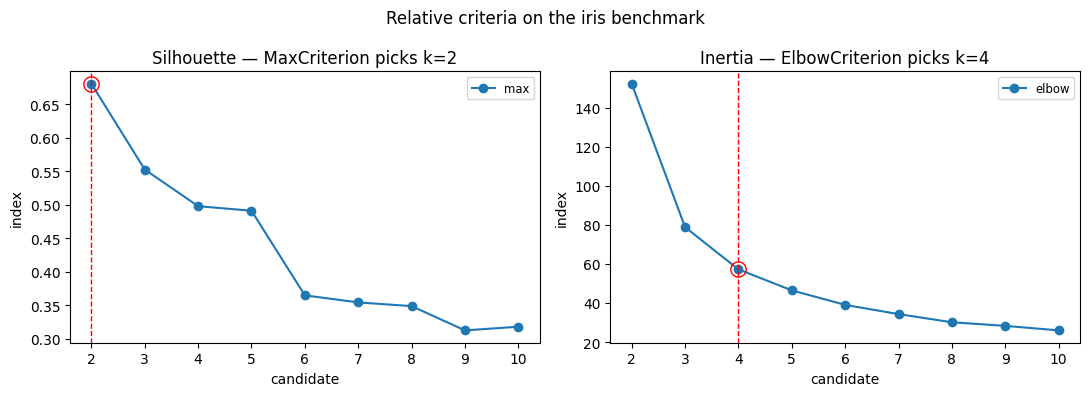

In [16]:
from xxcluster.viz.diagnostics import plot_selection_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
plot_selection_curve(max_crit.curve(silhouette_curve), selected=best_k, criterion="max", ax=ax1)
ax1.set_title(f"Silhouette — MaxCriterion picks k={best_k}")
plot_selection_curve(elbow_crit.curve(inertia_curve), selected=elbow_k, criterion="elbow", ax=ax2)
ax2.set_title(f"Inertia — ElbowCriterion picks k={elbow_k}")
fig.suptitle("Relative criteria on the iris benchmark")
fig.tight_layout()
plt.show()

## 9. Summary

- `MaxCriterion` selected the silhouette peak; the minimised-index run selected
  the trough, so the direction is the index's, applied through `is_better`.
- `ElbowCriterion` selected the bend of the monotone inertia curve, which the
  maximum reads only as its final swept point.
- `is_conclusive` declined the flat, monotone, and straight curves.

These are the three claims Sect. 7.1 rests on.